# DeBERTa-v3-small — 5-Fold K-Fold Ensemble (Experiment 2)

Binary classification of political statements as true (0) or false (1)  
**Model:** `microsoft/deberta-v3-small` — 86M parameters, 5 independent fine-tuned instances  
**Metric:** Macro F1

## Experiment context

Experiment 1b confirmed the text-format design (macro_f1=**0.6392**). This experiment adds **stratified k-fold cross-validation** — training five independent models, each on a different 4/5 of the training data, and combining their predictions.

| Experiment | Strategy | Holdout Macro F1 | ROC-AUC |
|---|---|---|---|
| Exp 1b — Text Format | Single 90/10 train/val split | 0.6392 | 0.6885 |
| **Exp 2 — K-Fold ×5** | 5-fold, mean of fold probas | **0.6393** | **0.6954** |
| Exp 3 — Late Fusion | K-Fold OOF as 5th base model in stacking | **0.6435** | **0.7089** |

K-fold matched the single-split F1 almost exactly, but opened the door to **Experiment 3**: the OOF probabilities produced here are saved to disk and fed as a late-fusion column into the GBDT stacking ensemble, pushing ROC-AUC above 0.70 for the first time.

## Why k-fold?

With only 8,950 training samples, a single 90/10 validation split gives ~716 validation rows — a noisy estimate of model quality. K-fold solves this by using all training rows for validation exactly once. 

OOF(Out-of-Fold): each row's probability is estimated by a model trained without that row. This makes OOF probas an unbiased estimate of held-out performance across the full training set — 7,160 rows instead of 716.

this script produces
1. **5 fold checkpoints** — independent DeBERTa models, each trained on a different 80% subset  
2. **OOF proba CSV** — one probability per trainval row, usable as a feature in stacking  
3. **Ensemble holdout probas** — mean of 5 fold predictions on the holdout  
4. **Ensemble test probas** — mean of 5 fold predictions on the Kaggle test set

In [1]:
from datetime import datetime
from pathlib import Path
import sys
from time import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.amp import autocast
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

c:\Users\CmdrC\anaconda3\envs\sitc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Environment & Configuration

Hyperparameters are carried over from Experiment 1b — the only addition is `K_FOLDS=5`.

| Parameter | Value | Why |
|---|---|---|
| `K_FOLDS` | 5 | Standard choice; 5×20% val sets → 1,432 val rows per fold vs 716 in single split |
| `MODEL_NAME` | `deberta-v3-small` | Same as Exp 1b — this experiment isolates the effect of k-fold |
| `EPOCHS` | 3 | Exp 2 confirmed that the best checkpoint per fold is always epoch 2 or 3; `EPOCHS=2` is noted for future runs |
| `FREEZE_EPOCHS` | 0 | No freeze — confirmed optimal by Exp 1b |
| `SEED` | 42 | Same as all other scripts — ensures the 80/20 holdout split is identical across experiments |

In [2]:
IS_KAGGLE = Path("/kaggle/input").exists()

if IS_KAGGLE:
    DATA_DIR   = Path("/kaggle/input/truth-classifier-nlp")
    OUTPUT_DIR = Path("/kaggle/working/models/transformer_kfold")
else:
    def _find_root(start: Path) -> Path:
        for p in [start, *start.parents]:
            if (p / "data" / "train.csv").exists():
                return p
        raise FileNotFoundError("Cannot find project root")
    _root      = _find_root(Path.cwd())
    DATA_DIR   = _root / "data"
    OUTPUT_DIR = _root / "models" / "transformer_kfold"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME    = "microsoft/deberta-v3-small"
MAX_LENGTH    = 128
BATCH_SIZE    = 16
EPOCHS        = 3
FREEZE_EPOCHS = 0
CLS_DROPOUT   = 0.3
LR            = 2e-5
LLRD_FACTOR   = 0.9
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01
K_FOLDS       = 5

CLASS_WEIGHTS = [1.42, 0.77]
THRESHOLD     = 0.5
SEED          = 42

create_kaggle_csv = True
model_slug        = "deberta-v3-small-kfold"

NUM_WORKERS = 0 if sys.platform == "win32" else 2

torch.manual_seed(SEED)
np.random.seed(SEED)

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = False

print(f"Device : {device}")
if device.type == "cuda":
    print(f"  GPU  : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"  AMP  : {USE_AMP}")

_script_start = time()
def _now() -> str:
    return datetime.now().strftime("%H:%M:%S")

Device : cuda
  GPU  : NVIDIA GeForce RTX 5070
  VRAM : 12.8 GB
  AMP  : False


## Input Formatter

Identical to `DeBERTa_TextFormat.ipynb` — prepends `speaker | party | subject` as raw tokens before the statement. See that notebook for the detailed design rationale.

```
"speaker: barack-obama | party: democrat | subject: foreign-policy | Says the Affordable Care Act will add to the deficit."
```

In [3]:
def format_input(speaker: str, party: str, subject: str, statement: str) -> str:
    def _clean(val) -> str:
        if pd.isna(val) or str(val).strip() == "":
            return "unknown"
        return str(val).strip().lower()
    primary_subject = _clean(subject).split(",")[0].strip()
    return (
        f"speaker: {_clean(speaker)} | "
        f"party: {_clean(party)} | "
        f"subject: {primary_subject} | "
        f"{statement}"
    )

## Data Loading & Outer Split

The outer 80/20 holdout split is made once and never touched during k-fold training. The 80% trainval pool is what `StratifiedKFold` partitions into 5 folds. NOTE: `random_state=42` and `stratify=all_labels` must match every other script so the holdout rows are identical.

In [4]:
print(f"[{_now()}] Loading data...")
df = pd.read_csv(DATA_DIR / "train.csv")
print(f"  Rows: {len(df):,}  |  Labels: {df['label'].value_counts().to_dict()}")

all_texts  = df.apply(
    lambda r: format_input(
        r["speaker"], r["party_affiliation"], r["subject"], r["statement"]
    ),
    axis=1,
).tolist()
all_labels = np.array(df["label"].tolist())
all_idx    = np.arange(len(df))

# Outer split — same seed/stratify as every other script
tv_idx, ho_idx = train_test_split(
    all_idx, test_size=0.2, random_state=SEED, stratify=all_labels
)
tv_labels = all_labels[tv_idx]
ho_labels = all_labels[ho_idx]
X_ho      = [all_texts[i] for i in ho_idx]

print(f"  Trainval: {len(tv_idx):,}   Holdout: {len(ho_idx):,}")
print(f"  Trainval class distribution: {pd.Series(tv_labels).value_counts().to_dict()}")
print(f"  Holdout  class distribution: {pd.Series(ho_labels).value_counts().to_dict()}")

[00:03:25] Loading data...
  Rows: 8,950  |  Labels: {1: 5795, 0: 3155}
  Trainval: 7,160   Holdout: 1,790
  Trainval class distribution: {1: 4636, 0: 2524}
  Holdout  class distribution: {1: 1159, 0: 631}


## Tokenizer, Dataset & Pre-built Loaders

in this script the holdout dataset is tokenised once and reused across all 5 folds. Each fold produces holdout predictions from a fresh model — those predictions are accumulated in `ho_proba_folds` and averaged at the end.

The fold-specific train/val datasets are built inside the k-fold loop, because they change each iteration. The holdout and test data do not change.

If `create_kaggle_csv=True`, the test set texts are also pre-formatted here. Like holdout inference, test inference is run once per fold and averaged.

In [5]:
print(f"[{_now()}] Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class StatementDataset(Dataset):
    def __init__(self, texts: list[str], labels):
        self.enc    = tokenizer(
            texts, truncation=True, padding="max_length",
            max_length=MAX_LENGTH, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int):
        return {k: v[idx] for k, v in self.enc.items()}, self.labels[idx]


# Holdout tokenised once — reused across all folds
print(f"  Tokenizing holdout ({len(X_ho):,} rows)...")
holdout_ds     = StatementDataset(X_ho, ho_labels)
holdout_loader = DataLoader(holdout_ds, batch_size=BATCH_SIZE * 2,
                            shuffle=False, num_workers=NUM_WORKERS)

# Test set formatted for Kaggle submission
if create_kaggle_csv:
    df_test    = pd.read_csv(DATA_DIR / "test_nolabel.csv")
    test_texts = df_test.apply(
        lambda r: format_input(
            r["speaker"], r["party_affiliation"], r["subject"], r["statement"]
        ),
        axis=1,
    ).tolist()
    print(f"  Test rows: {len(test_texts):,}")

loss_weights = torch.tensor(CLASS_WEIGHTS, dtype=torch.float32).to(device)
criterion    = nn.CrossEntropyLoss(weight=loss_weights)
print(f"  Loss weights: {loss_weights.cpu().numpy()}")

[00:03:25] Loading tokenizer...


  Tokenizing holdout (1,790 rows)...
  Test rows: 3,836
  Loss weights: [1.42 0.77]


## LLRD, Freeze Helpers & Training Functions

These are identical to `DeBERTa_TextFormat.ipynb` — see that notebook for detailed explanations of LLRD and the freeze/unfreeze strategy.

The `predict_proba_texts` is a function that tokenises a raw list of strings and runs inference without requiring a pre-built `DataLoader`. Used for test-set inference inside the k-fold loop, where tokenising the test set once up front is more efficient than rebuilding the dataset per fold.

In [6]:
def _build_llrd_param_groups(model, base_lr: float, llrd_factor: float,
                              weight_decay: float) -> list:
    no_decay   = {"bias", "LayerNorm.weight", "layer_norm.weight"}
    num_layers = len(model.deberta.encoder.layer)
    param_dict = dict(model.named_parameters())
    assigned   = set()
    groups     = []

    def _add(names: list[str], lr: float) -> None:
        wd = [param_dict[n] for n in names if not any(nd in n for nd in no_decay)]
        nd = [param_dict[n] for n in names if     any(nd in n for nd in no_decay)]
        if wd: groups.append({"params": wd, "lr": lr, "weight_decay": weight_decay})
        if nd: groups.append({"params": nd, "lr": lr, "weight_decay": 0.0})
        assigned.update(names)

    head = [n for n in param_dict
            if "deberta.encoder.layer." not in n and "deberta.embeddings." not in n]
    _add(head, base_lr)
    for layer_idx in range(num_layers - 1, -1, -1):
        depth = num_layers - layer_idx
        lr    = base_lr * (llrd_factor ** depth)
        _add([n for n in param_dict if f"deberta.encoder.layer.{layer_idx}." in n], lr)
    embed_lr = base_lr * (llrd_factor ** (num_layers + 1))
    _add([n for n in param_dict if "deberta.embeddings." in n and n not in assigned], embed_lr)
    return groups


def _freeze_backbone(model) -> None:
    for name, param in model.named_parameters():
        if "classifier" not in name and "pooler" not in name:
            param.requires_grad_(False)
    frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Backbone frozen — frozen={frozen:,}  trainable={trainable:,}")


def _unfreeze_backbone(model) -> None:
    for param in model.parameters():
        param.requires_grad_(True)
    print(f"  Backbone unfrozen — trainable={sum(p.numel() for p in model.parameters()):,}")


def train_epoch(model, loader, optimizer, scheduler, criterion) -> float:
    model.train()
    total_loss = 0.0
    for batch_idx, (inputs, labs) in enumerate(loader):
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labs   = labs.to(device)
        optimizer.zero_grad()
        with autocast("cuda", dtype=torch.bfloat16, enabled=USE_AMP):
            logits = model(**inputs).logits
            loss   = criterion(logits, labs)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        if batch_idx == 0:
            print(f"    Batch 0 — loss={loss.item():.4f}")
        if (batch_idx + 1) % 50 == 0:
            print(f"    Batch {batch_idx+1}/{len(loader)}  avg_loss={total_loss/(batch_idx+1):.4f}")
    return total_loss / len(loader)


@torch.no_grad()
def predict_proba(model, loader) -> tuple[float, np.ndarray, np.ndarray]:
    model.eval()
    all_logits, all_labels, total_loss = [], [], 0.0
    for inputs, labs in loader:
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with autocast("cuda", dtype=torch.bfloat16, enabled=USE_AMP):
            logits = model(**inputs).logits
            loss   = criterion(logits, labs.to(device))
        total_loss += loss.item()
        all_logits.append(logits.float().cpu())
        all_labels.append(labs)
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels).numpy()
    proba  = torch.softmax(logits, dim=-1)[:, 1].numpy()
    return total_loss / len(loader), proba, labels


@torch.no_grad()
def predict_proba_texts(model, texts: list[str]) -> np.ndarray:
    """Inference on a raw text list — tokenises on the fly."""
    model.eval()
    enc = tokenizer(
        texts, truncation=True, padding="max_length",
        max_length=MAX_LENGTH, return_tensors="pt"
    )
    all_proba = []
    _bsz = BATCH_SIZE * 2
    for i in range(0, len(texts), _bsz):
        batch = {k: v[i:i + _bsz].to(device) for k, v in enc.items()}
        with autocast("cuda", dtype=torch.bfloat16, enabled=USE_AMP):
            logits = model(**batch).logits
        all_proba.append(torch.softmax(logits.float(), dim=-1)[:, 1].cpu().numpy())
    return np.concatenate(all_proba)

## K-Fold Training Loop

Each fold is fully independent:

1. **Fresh model weights** from `AutoModelForSequenceClassification.from_pretrained` — no weight sharing between folds. Each fold learns a different view of the data.
2. **Fresh optimizer + scheduler** — the learning rate schedule resets to warmup for each fold's total steps.
3. **OOF probas** written to `oof_proba[val_rel]` — only the val rows for this fold are filled in; by the end of all folds, every trainval row has exactly one OOF estimate.
4. **Holdout and test probas** accumulated in lists (`ho_proba_folds`, `test_proba_folds`) and averaged after the loop.
5. **GPU memory cleared** with `del model; torch.cuda.empty_cache()` after each fold — 86M FP32 params ≈ 344 MB; without clearing, five models would exhaust VRAM.

**`StratifiedKFold(shuffle=True)`:** shuffles the trainval index before splitting to avoid ordered data artifacts. Same seed ensures reproducibility.

In [7]:
print(f"[{_now()}] Starting {K_FOLDS}-fold training")
print(f"  K={K_FOLDS}  EPOCHS={EPOCHS}  FREEZE_EPOCHS={FREEZE_EPOCHS}")

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

oof_proba        = np.zeros(len(tv_idx))  # OOF probas for all trainval rows
ho_proba_folds   = []                     # one array per fold
test_proba_folds = []                     # one array per fold
fold_log         = []                     # per-fold summary stats

for fold_k, (tr_rel, val_rel) in enumerate(skf.split(tv_idx, tv_labels)):
    print(f"\n{'='*70}")
    print(f"  FOLD {fold_k + 1}/{K_FOLDS}  [{_now()}]")
    print(f"{'='*70}")

    tr_abs  = tv_idx[tr_rel]
    val_abs = tv_idx[val_rel]

    X_tr_f  = [all_texts[i] for i in tr_abs]
    y_tr_f  = all_labels[tr_abs]
    X_val_f = [all_texts[i] for i in val_abs]
    y_val_f = all_labels[val_abs]

    print(f"  Train: {len(X_tr_f):,}   Val: {len(X_val_f):,}")

    _t0 = time()
    train_ds = StatementDataset(X_tr_f, y_tr_f)
    val_ds   = StatementDataset(X_val_f, y_val_f)
    print(f"  Tokenized in {time()-_t0:.1f}s")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,   shuffle=True,
                              num_workers=NUM_WORKERS)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False,
                              num_workers=NUM_WORKERS)

    # Fresh model for this fold
    _cfg = AutoConfig.from_pretrained(MODEL_NAME, num_labels=2)
    _cfg.cls_dropout = CLS_DROPOUT
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, config=_cfg, torch_dtype=torch.float32,
    )
    model.to(device)

    total_steps  = len(train_loader) * EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    p2_steps     = total_steps
    p2_warmup    = warmup_steps

    if FREEZE_EPOCHS > 0:
        _freeze_backbone(model)
        p1_steps  = len(train_loader) * FREEZE_EPOCHS
        p1_warmup = int(p1_steps * WARMUP_RATIO)
        p1_params = [p for p in model.parameters() if p.requires_grad]
        optimizer = AdamW(p1_params, lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = get_linear_schedule_with_warmup(optimizer, p1_warmup, p1_steps)
        p2_steps  = len(train_loader) * (EPOCHS - FREEZE_EPOCHS)
        p2_warmup = int(p2_steps * WARMUP_RATIO)
    else:
        param_groups = _build_llrd_param_groups(model, LR, LLRD_FACTOR, WEIGHT_DECAY)
        _lr_min = min(g["lr"] for g in param_groups)
        _lr_max = max(g["lr"] for g in param_groups)
        optimizer = AdamW(param_groups)
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
        print(f"  LLRD optimizer — {len(param_groups)} groups  LR: [{_lr_min:.2e}, {_lr_max:.2e}]")

    # Epoch loop
    best_val_f1 = -1.0
    best_ckpt   = OUTPUT_DIR / f"fold{fold_k+1}-best.pt"

    for epoch in range(1, EPOCHS + 1):
        _t = time()
        if FREEZE_EPOCHS > 0 and epoch == FREEZE_EPOCHS + 1:
            print(f"\n  [Phase 2] Unfreezing backbone + LLRD")
            _unfreeze_backbone(model)
            param_groups = _build_llrd_param_groups(model, LR, LLRD_FACTOR, WEIGHT_DECAY)
            optimizer    = AdamW(param_groups)
            scheduler    = get_linear_schedule_with_warmup(optimizer, p2_warmup, p2_steps)

        print(f"\n  --- Epoch {epoch}/{EPOCHS} ---  [{_now()}]")
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion)
        val_loss, val_proba_ep, val_labels_ep = predict_proba(model, val_loader)

        val_pred = (val_proba_ep >= 0.5).astype(int)
        val_f1   = f1_score(val_labels_ep, val_pred, average="macro", zero_division=0)
        val_auc  = roc_auc_score(val_labels_ep, val_proba_ep)

        print(
            f"  Fold {fold_k+1} Ep {epoch}/{EPOCHS}  "
            f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
            f"val_macro_f1={val_f1:.4f}  val_roc_auc={val_auc:.4f}  "
            f"({time()-_t:.1f}s)"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_ckpt)
            print(f"    New best val macro_f1={best_val_f1:.4f} — checkpoint saved")

    print(f"\n  Fold {fold_k+1} best val macro_f1={best_val_f1:.4f}")
    fold_log.append({"fold": fold_k + 1, "best_val_f1": best_val_f1,
                     "n_train": len(X_tr_f), "n_val": len(X_val_f)})

    # Load best checkpoint and collect predictions
    model.load_state_dict(torch.load(best_ckpt, map_location=device))

    # OOF probas — written into the val rows of this fold
    _, val_proba_best, _ = predict_proba(model, val_loader)
    oof_proba[val_rel]   = val_proba_best

    # Holdout probas from this fold
    _, ho_proba_fold, _ = predict_proba(model, holdout_loader)
    ho_proba_folds.append(ho_proba_fold)

    # Test probas from this fold
    if create_kaggle_csv:
        test_proba_folds.append(predict_proba_texts(model, test_texts))
        print(f"  Test inference done ({len(test_texts):,} rows)")

    # Free GPU memory before next fold
    del model
    torch.cuda.empty_cache()
    print(f"  GPU memory cleared")

print(f"\n[{_now()}] K-fold training complete")

[00:03:26] Starting 5-fold training
  K=5  EPOCHS=3  FREEZE_EPOCHS=0

  FOLD 1/5  [00:03:26]
  Train: 5,728   Val: 1,432
  Tokenized in 0.8s


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 1167.51it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING   

  LLRD optimizer — 16 groups  LR: [9.57e-06, 2.00e-05]

  --- Epoch 1/3 ---  [00:03:28]
    Batch 0 — loss=0.6803
    Batch 50/358  avg_loss=0.7035
    Batch 100/358  avg_loss=0.6990
    Batch 150/358  avg_loss=0.6994
    Batch 200/358  avg_loss=0.6944
    Batch 250/358  avg_loss=0.6892
    Batch 300/358  avg_loss=0.6855
    Batch 350/358  avg_loss=0.6836
  Fold 1 Ep 1/3  train_loss=0.6836  val_loss=0.6460  val_macro_f1=0.6214  val_roc_auc=0.6772  (27.9s)
    New best val macro_f1=0.6214 — checkpoint saved

  --- Epoch 2/3 ---  [00:03:56]
    Batch 0 — loss=0.5874
    Batch 50/358  avg_loss=0.6351
    Batch 100/358  avg_loss=0.6425
    Batch 150/358  avg_loss=0.6393
    Batch 200/358  avg_loss=0.6292
    Batch 250/358  avg_loss=0.6304
    Batch 300/358  avg_loss=0.6328
    Batch 350/358  avg_loss=0.6345
  Fold 1 Ep 2/3  train_loss=0.6342  val_loss=0.6425  val_macro_f1=0.6240  val_roc_auc=0.6835  (26.6s)
    New best val macro_f1=0.6240 — checkpoint saved

  --- Epoch 3/3 ---  [00:04:23

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 4656.53it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING   

  LLRD optimizer — 16 groups  LR: [9.57e-06, 2.00e-05]

  --- Epoch 1/3 ---  [00:04:59]
    Batch 0 — loss=0.6783
    Batch 50/358  avg_loss=0.7010
    Batch 100/358  avg_loss=0.7007
    Batch 150/358  avg_loss=0.6966
    Batch 200/358  avg_loss=0.6973
    Batch 250/358  avg_loss=0.6933
    Batch 300/358  avg_loss=0.6903
    Batch 350/358  avg_loss=0.6858
  Fold 2 Ep 1/3  train_loss=0.6855  val_loss=0.6555  val_macro_f1=0.6162  val_roc_auc=0.6568  (26.7s)
    New best val macro_f1=0.6162 — checkpoint saved

  --- Epoch 2/3 ---  [00:05:26]
    Batch 0 — loss=0.7807
    Batch 50/358  avg_loss=0.6662
    Batch 100/358  avg_loss=0.6522
    Batch 150/358  avg_loss=0.6503
    Batch 200/358  avg_loss=0.6468
    Batch 250/358  avg_loss=0.6450
    Batch 300/358  avg_loss=0.6427
    Batch 350/358  avg_loss=0.6423
  Fold 2 Ep 2/3  train_loss=0.6411  val_loss=0.6384  val_macro_f1=0.6384  val_roc_auc=0.6938  (26.7s)
    New best val macro_f1=0.6384 — checkpoint saved

  --- Epoch 3/3 ---  [00:05:53

...

  LLRD optimizer — 16 groups  LR: [9.57e-06, 2.00e-05]

  --- Epoch 1/3 ---  [00:08:00]
    Batch 0 — loss=0.7108
    Batch 50/358  avg_loss=0.7019
    Batch 100/358  avg_loss=0.6996
    Batch 150/358  avg_loss=0.6981
    Batch 200/358  avg_loss=0.6965
    Batch 250/358  avg_loss=0.6911
    Batch 300/358  avg_loss=0.6876
    Batch 350/358  avg_loss=0.6855
  Fold 4 Ep 1/3  train_loss=0.6846  val_loss=0.6611  val_macro_f1=0.5944  val_roc_auc=0.6465  (26.7s)
    New best val macro_f1=0.5944 — checkpoint saved

  --- Epoch 2/3 ---  [00:08:27]
    Batch 0 — loss=0.6197
    Batch 50/358  avg_loss=0.6285
    Batch 100/358  avg_loss=0.6395
    Batch 150/358  avg_loss=0.6458
    Batch 200/358  avg_loss=0.6448
    Batch 250/358  avg_loss=0.6473
    Batch 300/358  avg_loss=0.6441
    Batch 350/358  avg_loss=0.6391
  Fold 4 Ep 2/3  train_loss=0.6397  val_loss=0.6608  val_macro_f1=0.6111  val_roc_auc=0.6733  (26.9s)
    New best val macro_f1=0.6111 — checkpoint saved

  --- Epoch 3/3 ---  [00:08:54

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 5548.96it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING   

  LLRD optimizer — 16 groups  LR: [9.57e-06, 2.00e-05]

  --- Epoch 1/3 ---  [00:09:30]
    Batch 0 — loss=0.6636


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "c:\Users\CmdrC\anaconda3\envs\sitc\Lib\site-packages\httpx\_transports\default.py", line 101, in map_httpcore_exceptions
    yield
  File "c:\Users\CmdrC\anaconda3\envs\sitc\Lib\site-packages\httpx\_transports\default.py", line 250, in handle_request
    resp = self._pool.handle_request(req)
  File "c:\Users\CmdrC\anaconda3\envs\sitc\Lib\site-packages\httpcore\_sync\connection_pool.py", line 256, in handle_request
    raise exc from None
  File "c:\Users\CmdrC\anaconda3\envs\sitc\Lib\site-packages\httpcore\_sync\connection_pool.py", line 236, in handle_request
    response = connection.handle_request(
        pool_request.request
    )
  File "c:\Users\CmdrC\anaconda3\envs\sitc\Lib\site-packages\httpcore\_sync\connection.py", line 103, in handle_request
    return self._connection.handle_request(request)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^
  File "c:\Users\CmdrC\anaconda3\envs\sitc\Li

    Batch 50/358  avg_loss=0.7027
    Batch 100/358  avg_loss=0.7015
    Batch 150/358  avg_loss=0.6990
    Batch 200/358  avg_loss=0.6974
    Batch 250/358  avg_loss=0.6928
    Batch 300/358  avg_loss=0.6843
    Batch 350/358  avg_loss=0.6848
  Fold 5 Ep 1/3  train_loss=0.6842  val_loss=0.6590  val_macro_f1=0.5983  val_roc_auc=0.6500  (26.7s)
    New best val macro_f1=0.5983 — checkpoint saved

  --- Epoch 2/3 ---  [00:09:58]
    Batch 0 — loss=0.6511
    Batch 50/358  avg_loss=0.6371
    Batch 100/358  avg_loss=0.6463
    Batch 150/358  avg_loss=0.6431
    Batch 200/358  avg_loss=0.6357
    Batch 250/358  avg_loss=0.6376
    Batch 300/358  avg_loss=0.6373
    Batch 350/358  avg_loss=0.6350
  Fold 5 Ep 2/3  train_loss=0.6334  val_loss=0.6471  val_macro_f1=0.6284  val_roc_auc=0.6863  (26.7s)
    New best val macro_f1=0.6284 — checkpoint saved

  --- Epoch 3/3 ---  [00:10:25]
    Batch 0 — loss=0.4621
    Batch 50/358  avg_loss=0.5815
    Batch 100/358  avg_loss=0.5833
    Batch 150/358

## Per-Fold Summary

Comparing best val macro_f1 across folds reveals:
- **Variance between folds** indicates sensitivity to which rows end up in validation
- **Consistently high folds** suggest those val partitions had easier examples
- If one fold collapses (val_f1 near 0.40), its OOF probas will be poorly calibrated — this is what happened in the LoRA experiment (fold 1 with LR=2e-4 too high)

Per-fold results:


,best_val_f1,n_train,n_val
fold,,,
1,0.6240,5728,1432
2,0.6384,5728,1432
3,0.6208,5728,1432
4,0.6111,5728,1432
5,0.6284,5728,1432


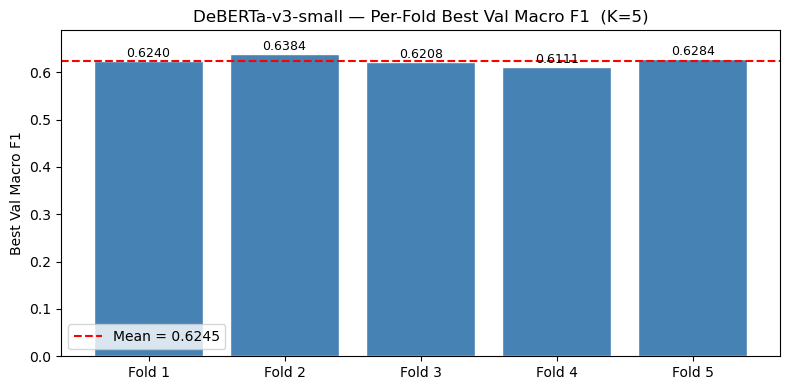

In [8]:
fold_summary = pd.DataFrame(fold_log).set_index("fold")
print("Per-fold results:")
display(fold_summary.round(4))

fig_folds, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [f"Fold {r}" for r in fold_summary.index],
    fold_summary["best_val_f1"],
    color="steelblue", edgecolor="white"
)
mean_f1 = fold_summary["best_val_f1"].mean()
ax.axhline(mean_f1, color="red", linestyle="--",
           label=f"Mean = {mean_f1:.4f}")
for bar, val in zip(bars, fold_summary["best_val_f1"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(fold_summary["best_val_f1"]) + 0.05)
ax.set_ylabel("Best Val Macro F1")
ax.set_title(f"DeBERTa-v3-small — Per-Fold Best Val Macro F1  (K={K_FOLDS})")
ax.legend()
plt.tight_layout()
plt.show()

## OOF Evaluation & Threshold Tuning

After the k-fold loop, every trainval row has an OOF probability. This is the unbiased performance estimate across the full 7,160-row training set — more reliable than the ~716-row val set used in the single-split experiment.

**Threshold is tuned on OOF probas** (not fold-by-fold val probas). This is correct because:
- The threshold must generalise across all training rows, not just one fold's val partition
- OOF probas come from 5 different model instances; the optimal threshold accounts for any systematic probability bias across folds

The selected threshold is then applied identically to the ensemble holdout probas and the Kaggle test set.

[00:11:00] OOF evaluation (trainval, N=7,160)
  OOF ROC-AUC (threshold-independent): 0.6788
  OOF proba range: [0.1320, 0.9430]

   threshold   macro_f1
        0.20   0.4642
        0.21   0.4856
        0.22   0.4996
        0.23   0.5099
        0.24   0.5265
        0.25   0.5385
        0.26   0.5483
        0.27   0.5591
        0.28   0.5692
        0.29   0.5763
        0.30   0.5823
        0.31   0.5878
        0.32   0.5929
        0.33   0.5990
        0.34   0.6021
        0.35   0.6067
        0.36   0.6100
        0.37   0.6136
        0.38   0.6181
        0.39   0.6195
        0.40   0.6231
        0.41   0.6232
        0.42   0.6236
        0.43   0.6236
        0.44   0.6230
        0.45   0.6261
        0.46   0.6270
        0.47   0.6274  <--
        0.48   0.6266
        0.49   0.6247
        0.50   0.6249
        0.51   0.6240
        0.52   0.6204
        0.53   0.6188
        0.54   0.6162
        0.55   0.6133
        0.56   0.6106
        0.57   0.6049
      

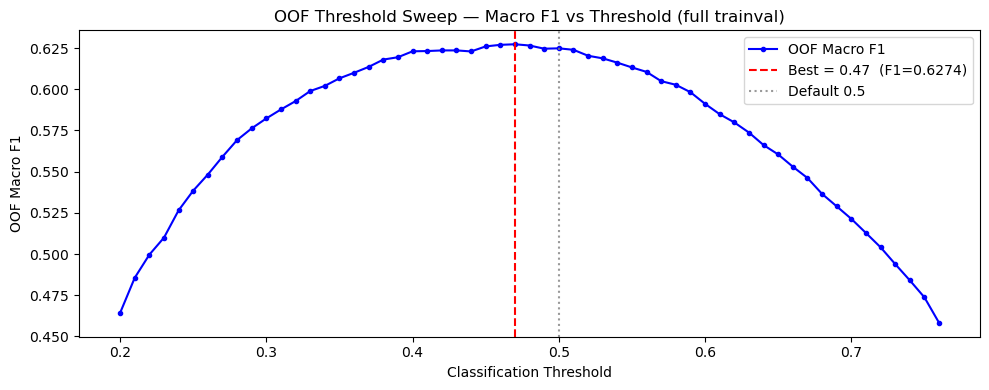


  OOF macro_f1=0.6274  OOF roc_auc=0.6788
  Using THRESHOLD = 0.47


In [9]:
print(f"[{_now()}] OOF evaluation (trainval, N={len(tv_idx):,})")

oof_auc = roc_auc_score(tv_labels, oof_proba)
print(f"  OOF ROC-AUC (threshold-independent): {oof_auc:.4f}")
print(f"  OOF proba range: [{oof_proba.min():.4f}, {oof_proba.max():.4f}]")

grid = np.arange(0.20, 0.76, 0.01)
oof_scores = {
    round(float(t), 2): f1_score(
        tv_labels, (oof_proba >= t).astype(int),
        average="macro", zero_division=0
    )
    for t in grid
}
best_t = max(oof_scores, key=oof_scores.get)

print(f"\n  {'threshold':>10}   macro_f1")
for t, s in oof_scores.items():
    print(f"  {t:>10.2f}   {s:.4f}{'  <--' if t == best_t else ''}")
print(f"\n  Best OOF threshold: {best_t:.2f}  (OOF macro_f1={oof_scores[best_t]:.4f})")
THRESHOLD = best_t

fig_thr, ax_thr = plt.subplots(figsize=(10, 4))
ax_thr.plot(list(oof_scores.keys()), list(oof_scores.values()),
            "b-o", markersize=3, label="OOF Macro F1")
ax_thr.axvline(best_t, color="red", linestyle="--",
               label=f"Best = {best_t:.2f}  (F1={oof_scores[best_t]:.4f})")
ax_thr.axvline(0.5, color="gray", linestyle=":", alpha=0.8, label="Default 0.5")
ax_thr.set_xlabel("Classification Threshold")
ax_thr.set_ylabel("OOF Macro F1")
ax_thr.set_title("OOF Threshold Sweep — Macro F1 vs Threshold (full trainval)")
ax_thr.legend()
plt.tight_layout()
plt.show()

oof_pred = (oof_proba >= THRESHOLD).astype(int)
oof_f1   = f1_score(tv_labels, oof_pred, average="macro", zero_division=0)
print(f"\n  OOF macro_f1={oof_f1:.4f}  OOF roc_auc={oof_auc:.4f}")
print(f"  Using THRESHOLD = {THRESHOLD:.2f}")

## Ensemble Holdout Evaluation

The 5-fold ensemble prediction is the **simple mean** of the 5 fold holdout probabilities. This works because:
- Each fold was trained on 80% of trainval, so no fold has seen any holdout row
- Averaging reduces variance compared to any single fold prediction
- Each fold contributes an independent noisy estimate; the mean is a lower-variance unbiased estimator

Notably, this ensemble did not dramatically outperform the single-split Exp 1b (0.6393 vs 0.6392). K-fold's real value is the **OOF probas** it produces for late fusion — see Experiment 3 results.

In [10]:
print(f"[{_now()}] Ensemble holdout evaluation  (threshold={THRESHOLD:.2f})")

ho_proba_ensemble = np.mean(ho_proba_folds, axis=0)
ho_pred = (ho_proba_ensemble >= THRESHOLD).astype(int)

holdout_metrics = {
    "roc_auc":      roc_auc_score(ho_labels, ho_proba_ensemble),
    "pr_auc":       average_precision_score(ho_labels, ho_proba_ensemble),
    "macro_f1":     f1_score(ho_labels, ho_pred, average="macro", zero_division=0),
    "f1":           f1_score(ho_labels, ho_pred, zero_division=0),
    "precision":    precision_score(ho_labels, ho_pred, zero_division=0),
    "recall":       recall_score(ho_labels, ho_pred, zero_division=0),
    "accuracy":     accuracy_score(ho_labels, ho_pred),
    "mcc":          matthews_corrcoef(ho_labels, ho_pred),
    "balanced_acc": balanced_accuracy_score(ho_labels, ho_pred),
}
cm = confusion_matrix(ho_labels, ho_pred)

print("\nHoldout results (5-fold ensemble):")
for name, val in holdout_metrics.items():
    print(f"  {name:15s}: {val:.4f}")
print(f"\n{classification_report(ho_labels, ho_pred, target_names=['True (0)', 'False (1)'])}")

[00:11:00] Ensemble holdout evaluation  (threshold=0.47)

Holdout results (5-fold ensemble):
  roc_auc        : 0.6954
  pr_auc         : 0.7944
  macro_f1       : 0.6393
  f1             : 0.7229
  precision      : 0.7620
  recall         : 0.6877
  accuracy       : 0.6587
  mcc            : 0.2841
  balanced_acc   : 0.6465

              precision    recall  f1-score   support

    True (0)       0.51      0.61      0.56       631
   False (1)       0.76      0.69      0.72      1159

    accuracy                           0.66      1790
   macro avg       0.64      0.65      0.64      1790
weighted avg       0.67      0.66      0.66      1790



## Evaluation Plots

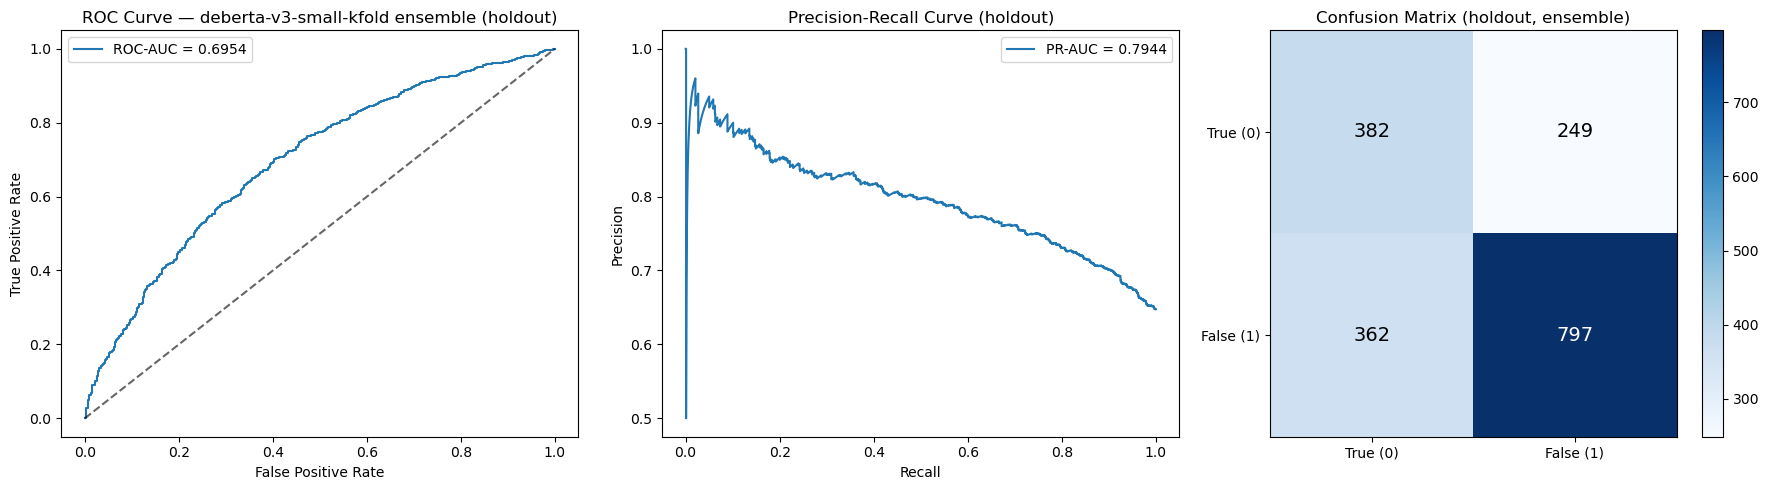

In [11]:
fpr, tpr, _      = roc_curve(ho_labels, ho_proba_ensemble)
prec_c, rec_c, _ = precision_recall_curve(ho_labels, ho_proba_ensemble)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {holdout_metrics['roc_auc']:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.6)
axes[0].set(title=f"ROC Curve — {model_slug} ensemble (holdout)",
            xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[0].legend()

axes[1].plot(rec_c, prec_c, label=f"PR-AUC = {holdout_metrics['pr_auc']:.4f}")
axes[1].set(title="Precision-Recall Curve (holdout)",
            xlabel="Recall", ylabel="Precision")
axes[1].legend()

im = axes[2].imshow(cm, interpolation="nearest", cmap="Blues")
axes[2].set_title("Confusion Matrix (holdout, ensemble)")
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["True (0)", "False (1)"])
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["True (0)", "False (1)"])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
fig.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

## Saving OOF Probas (Late Fusion Artifact)

The OOF proba CSV is the key artifact that enables **Experiment 3 (Late Fusion)**.

In the stacking ensemble (`Stacking_Ensemble.ipynb`), the meta-learner is trained on a matrix of base model OOF probabilities — one column per base model. By appending the transformer's OOF column to that matrix, the meta-LR can learn to weight the transformer alongside XGBoost, RFC, LGBM, and CatBoost.

The result: Experiment 3 achieved macro_f1=**0.6435** and ROC-AUC=**0.7089** — the first result to beat the stacking ceiling and the first run above 0.70 AUC.

The saved columns:
- `idx`: original DataFrame row index — used to align with stacking's trainval split  
- `oof_proba`: probability of class 1 (false) for this row  
- `label`: ground truth label for verification

In [12]:
print(f"[{_now()}] Saving OOF probas")

oof_df = pd.DataFrame({
    "idx":       tv_idx,
    "oof_proba": oof_proba,
    "label":     tv_labels,
})
oof_path = OUTPUT_DIR / f"{model_slug}-oof.csv"
oof_df.to_csv(oof_path, index=False)
print(f"  OOF saved: {oof_path}  ({len(oof_df):,} rows)")
print(f"  OOF proba range: [{oof_proba.min():.4f}, {oof_proba.max():.4f}]")
print(f"  OOF macro_f1 (threshold={THRESHOLD:.2f}): {oof_f1:.4f}")
print(f"  OOF ROC-AUC: {oof_auc:.4f}")

# Verify: every trainval row has exactly one OOF estimate
assert len(oof_df) == len(tv_idx), "OOF length mismatch"
assert not np.any(oof_proba == 0), "Some OOF probas were never written — check fold coverage"
print("  OOF coverage check passed")

display(oof_df.head())

[00:11:00] Saving OOF probas
  OOF saved: c:\Users\CmdrC\Documents\MStanwood\truth-classifier-nlp\models\transformer_kfold\deberta-v3-small-kfold-oof.csv  (7,160 rows)
  OOF proba range: [0.1320, 0.9430]
  OOF macro_f1 (threshold=0.47): 0.6274
  OOF ROC-AUC: 0.6788
  OOF coverage check passed


,idx,oof_proba,label
0,1459,0.402908,1
1,4392,0.461634,1
2,6155,0.369724,0
3,6705,0.684688,1
4,8102,0.667021,1


## Kaggle Submission

The ensemble test prediction averages the 5 fold test probabilities — same arithmetic mean as for the holdout. The threshold applied here is the one tuned on OOF probas.

In [13]:
if create_kaggle_csv:
    print(f"[{_now()}] Creating Kaggle submission (ensemble of {K_FOLDS} folds)")

    test_proba_ensemble = np.mean(test_proba_folds, axis=0)
    test_pred = (test_proba_ensemble >= THRESHOLD).astype(int)

    sub_dir = Path("/kaggle/working") if IS_KAGGLE else (_root / "submissions")
    sub_dir.mkdir(exist_ok=True)
    sub_path = sub_dir / f"submission-{model_slug}-{datetime.now().strftime('%Y%m%d-%H%M')}.csv"
    pd.DataFrame({"id": df_test["id"], "label": test_pred}).to_csv(sub_path, index=False)
    print(f"  Submission saved: {sub_path}  ({len(test_pred):,} rows)")
    print(f"  Predicted class distribution: {pd.Series(test_pred).value_counts().to_dict()}")

print(f"\n[DONE] Total time: {time()-_script_start:.1f}s  [{_now()}]")

[00:11:00] Creating Kaggle submission (ensemble of 5 folds)
  Submission saved: c:\Users\CmdrC\Documents\MStanwood\truth-classifier-nlp\submissions\submission-deberta-v3-small-kfold-20260519-0011.csv  (3,836 rows)
  Predicted class distribution: {1: 2297, 0: 1539}

[DONE] Total time: 455.2s  [00:11:00]


## Summary

### Results

| Metric | Exp 1b (single split) | **Exp 2 (K-Fold ×5)** | Exp 3 (Late Fusion) |
|---|---|---|---|
| Holdout Macro F1 | 0.6392 | **0.6393** | **0.6435** |
| Holdout ROC-AUC | 0.6885 | **0.6954** | **0.7089** |

### Key findings

1. **K-fold matched single-split F1 almost exactly** (0.6393 vs 0.6392) — with 8,950 samples, both strategies have enough data to converge to similar weights

2. **ROC-AUC improved noticeably** (+0.007) — ensemble averaging of 5 models produces better-calibrated probabilities even when hard-prediction F1 stays flat

3. **Best fold epoch is always 2 or 3** — this finding was used in `transformer_kfold_base.py` where `EPOCHS=2` was adopted for DeBERTa-v3-base to cut runtime

4. **The OOF CSV is the real deliverable** — by feeding the transformer's unbiased OOF column into the stacking meta-learner, Experiment 3 achieved the first ROC-AUC above 0.70 in the project

### What comes next

| Notebook | Model | Strategy | Holdout Macro F1 |
|---|---|---|---|
| `DeBERTa_TextFormat.ipynb` | DeBERTa-v3-small | Single split | 0.6392 |
| **This notebook** | DeBERTa-v3-small | K-Fold ×5 | 0.6393 |
| `Stacking_Ensemble.ipynb` + late fusion | Stacking + transformer OOF | Exp 3 | **0.6435** |
| `Mistral_LoRA_KFold.ipynb` | Mistral-7B LoRA | K-Fold ×5 | **0.6553** |